In [1]:
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
                                    StratifiedKFold, 
                                    cross_validate,
                                    train_test_split
                                    )
from sklearn.metrics import (
                            confusion_matrix,
                            f1_score,
                            accuracy_score,
                            precision_score,
                            recall_score
                            )
warnings.filterwarnings('ignore')

### 1. Load the data

In [2]:
from pathlib import Path

project_root = Path.cwd()
for parent in [project_root, *project_root.parents]:
    if (parent / 'artifacts').exists():
        project_root = parent
        break

with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_train.npz') as data:
    X_train = data['X_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_train.npz') as data:
    Y_train = data['y_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_test.npz') as data:
    X_test = data['X_test']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_test.npz') as data:
    Y_test = data['y_test']

### 2. Define Multi Models

In [7]:
models = {
        'Logistic Regression' : LogisticRegression(),
        'Decision Tree' : DecisionTreeClassifier(),
        'xgboost' : XGBClassifier(),
        'Random Forest' : RandomForestClassifier(),
        }

### 3. Configure K-Fold CV

In [8]:
cv = StratifiedKFold(
                    n_splits=6,
                    random_state=42,
                    shuffle=True
                    )

In [9]:
trained_models = {}
for model_name, model in models.items():
    print(f"\nCross Validation on {model_name}")

    cv_results = cross_validate(
                                model,
                                X_train, Y_train,
                                cv=cv, scoring='f1',
                                return_estimator=True,
                                return_train_score=False
                                )
    test_scores = cv_results['test_score']
    best_index = np.argmax(test_scores)

    estimator = cv_results['estimator'][best_index]
    trained_models[model_name] = estimator


Cross Validation on Logistic Regression

Cross Validation on Decision Tree

Cross Validation on xgboost

Cross Validation on Random Forest


In [10]:
trained_models

{'Logistic Regression': LogisticRegression(),
 'Decision Tree': DecisionTreeClassifier(),
 'xgboost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 'Random Forest': RandomForestClassifier()}

In [15]:
Y_hat_tests = {}
for model_name, model in trained_models.items():
    Y_hat_test = model.predict(X_test)
    Y_hat_tests[model_name] = Y_hat_test
Y_hat_tests

{'Logistic Regression': array([0, 0, 0, ..., 0, 0, 0], shape=(2000,)),
 'Decision Tree': array([0, 0, 0, ..., 0, 0, 0], shape=(2000,)),
 'xgboost': array([0, 0, 0, ..., 0, 0, 0], shape=(2000,)),
 'Random Forest': array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))}

In [16]:
cm1 = confusion_matrix(Y_test, Y_hat_tests['Logistic Regression'])
cm2 = confusion_matrix(Y_test, Y_hat_tests['Decision Tree'])
cm3 = confusion_matrix(Y_test, Y_hat_tests['Random Forest'])
cm4 = confusion_matrix(Y_test, Y_hat_tests['xgboost'])

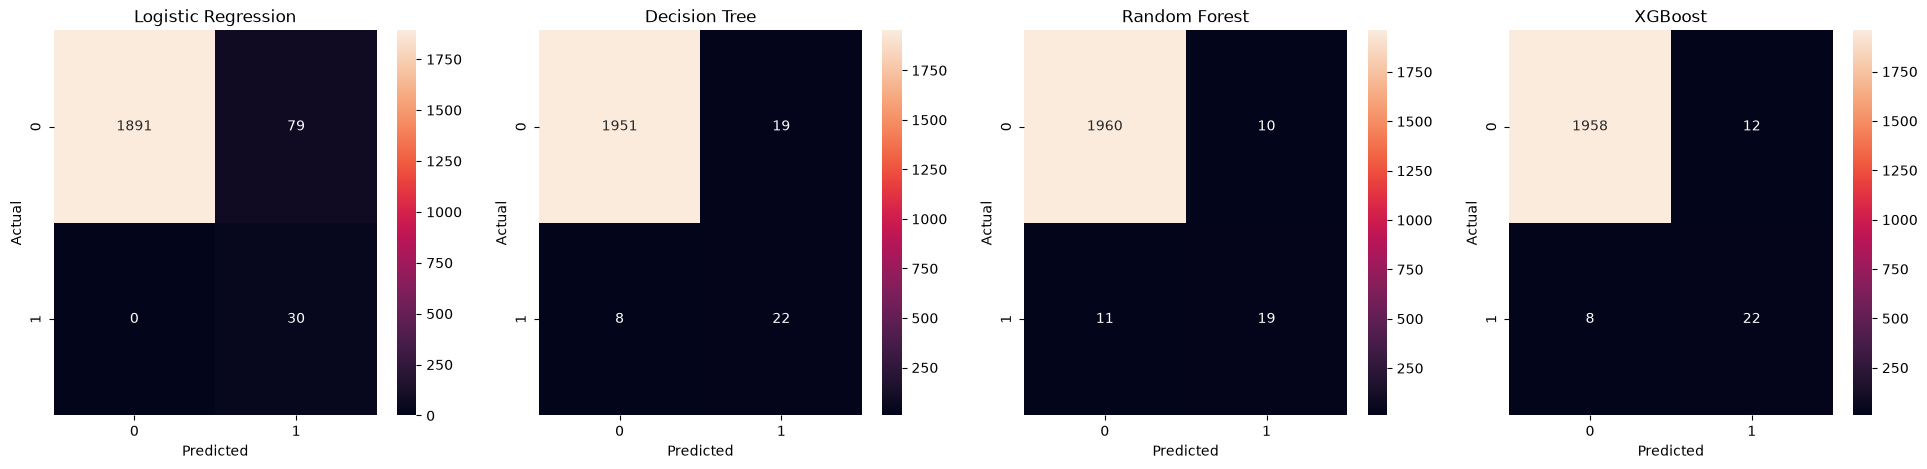

In [17]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize = (24, 5))

sns.heatmap(cm1, annot=True, fmt='d', ax=ax1)
ax1.set_title('Logistic Regression')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm2, annot=True, fmt='d', ax=ax2)
ax2.set_title('Decision Tree')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

sns.heatmap(cm3, annot=True, fmt='d', ax=ax3)
ax3.set_title('Random Forest')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

sns.heatmap(cm4, annot=True, fmt='d', ax=ax4)
ax4.set_title('XGBoost')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.show()